In [1]:
from nocode_robot_programming.state_decision.utils import kill_other_ipykernels
kill_other_ipykernels(force=True)
import trajectory_data
from dataloader import TrajectoryDataset
import matplotlib.pyplot as plt
from nocode_robot_programming.state_decision.dino_model import DINOStateDecider
from nocode_robot_programming.state_decision.SIFT_model import StateDeciderSIFT
from nocode_robot_programming.state_decision.AEGP_model import AEGP
from trajectory_data import skill_visualizer
from gesture_detector.utils import pretty_confusion_matrix
import torch
import numpy as np
import matplotlib.pyplot as plt

No other ipykernel_launcher processes found.


In [2]:
dataset = TrajectoryDataset(trajectory_data.package_path)

In [3]:
# decider = DINOStateDecider(dino_variant="dinov2_vits14", use_cls_token=True, batch_size=128, percent_keep=0.05)
# decider = StateDeciderSIFT()
decider = AEGP()

In [4]:
task_name = "peg_door404"

# Door Open/Close classification

peg_door404  is discarded as an alternative branch


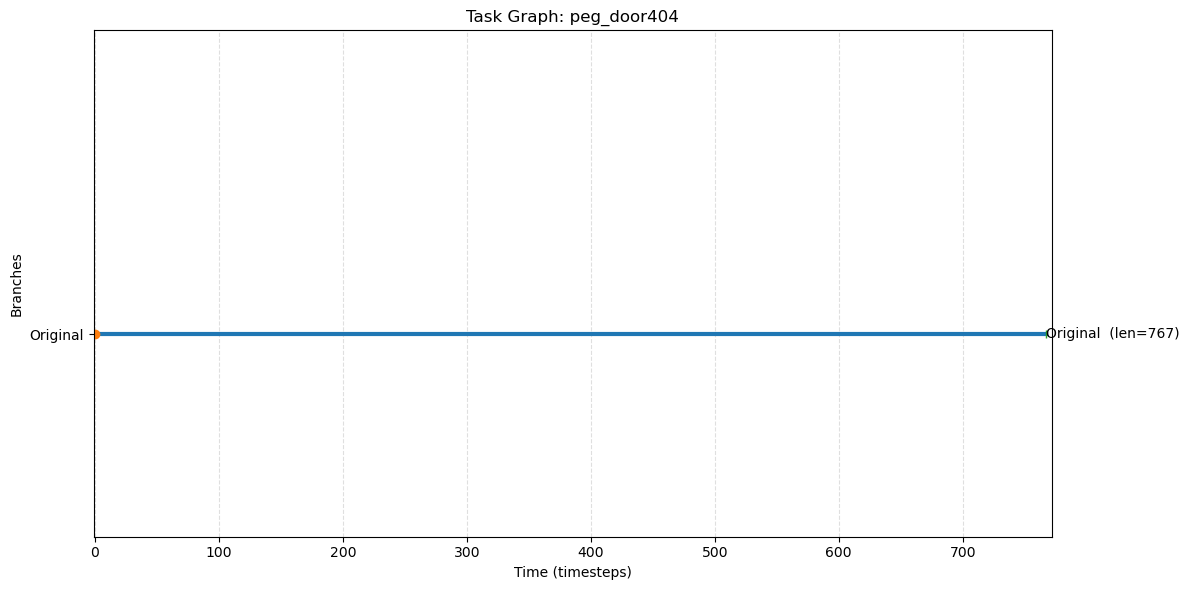

In [5]:

dataset.get_task_graph_structure(task_name)

In [6]:
d = dataset.get_image_dataset(dataset.get_all_names(task_name))

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

In [ ]:
d.X.shape

In [ ]:
decider.train(d.X, d.y_int, d.y_cls)

In [ ]:
def predict(decider, X):
    y_pred = []
    for x in X:
        probs,y_label = decider.predict(x)
        y_pred.append(y_label)
    return y_pred

In [ ]:
plt.imshow(d.X[0].cpu())

In [ ]:
decider.videoembedder.model.eval()
image = d.X[2]
with torch.no_grad():
    latent = decider.videoembedder.model.encoder(image.unsqueeze(0).unsqueeze(0)) # (1, 1, width, height), 4D
    out = decider.videoembedder.model.decoder(latent)
plt.imshow(out.squeeze().detach().cpu())

In [ ]:
y_pred = predict(decider, d.X)


In [ ]:
pretty_confusion_matrix.pp_matrix_from_string_data(d.y_names, y_pred, figsize=(6,6))

In [ ]:
import torch, torchvision
a = torch.tensor([[0,1,2,3]])


t = torchvision.transforms.ToTensor()
t(a.numpy())